# N8 — Planning em Agentes LLMs

* Professor: Julio Cesar dos Reis <a href="mailto:dosreis@unicamp.br">(dosreis@unicamp.br)</a>
* Monitor: Renan dos Santos Morais <a href="mailto:r299211@dac.unicamp.br">(r299211@dac.unicamp.br)</a> 

Este notebook apresenta técnicas de planejamento em agentes LLMs. As técnicas tratam o problema de **como um agente decide a sequência de ações que vai tomar** para resolver uma tarefa complexa.

Vamos estudar cinco estratégias de planejamento, todas amplamente discutidas na literatura de agentes baseados em LLM:

1. **ReAct** — raciocínio e ação intercalados (recapitulação);
2. **Plan-and-Execute** — planeja tudo antes, depois executa passo a passo;
3. **ReWOO** — planeja sem observação intermediária, com substituição de variáveis;
4. **Reflection** — gera, critica e revisa a própria saída;
5. **Tree of Thoughts (ToT)** — explora múltiplos caminhos de raciocínio em paralelo e escolhe o melhor.

## 0.1 Pré-requisitos

Para acompanhar este notebook, é esperado que você já tenha:

- visto o padrão ReAct e tool calling (notebook de Ferramentas);
- construído grafos com estado, nós e arestas condicionais em LangGraph;
- usado saída estruturada com `with_structured_output` e Pydantic (notebook de LangGraph com LLMs, seção do ciclo gerar → avaliar → revisar);
- familiaridade básica com `TypedDict`, `Literal` e listas em Python.

Não é necessário nenhum pacote específico de planejamento. Cada estratégia será implementada com LangGraph puro, exatamente como fizemos até aqui.

## 0.2 Objetivos da aula

Ao final deste notebook, você deverá saber:

1. Explicar as limitações do ReAct puro em tarefas longas ou complexas.
2. Diferenciar as cinco estratégias de planejamento estudadas.
3. Implementar um agente Plan-and-Execute com planejador, executor e replanejador.
4. Implementar um agente ReWOO, com plano fechado e substituição de variáveis.
5. Reconhecer e estender o padrão Reflection (generator + reflector).
6. Implementar uma versão simplificada de Tree of Thoughts.
7. Comparar as estratégias em termos de custo, latência e adequação a diferentes tarefas.
8. Escolher a estratégia adequada para um problema novo.

## 0.3 Mapa do notebook

Este notebook cobrirá os seguintes tópicos:

1. Por que ReAct nem sempre é suficiente.
2. Panorama das cinco estratégias.
3. Plan-and-Execute.
4. ReWOO.
5. Reflection.
6. Tree of Thoughts.
7. Comparando as cinco estratégias.
8. Como escolher uma estratégia.
9. Exercícios de fixação.
10. Resumo da aula.
11. Referências.

## 0.4 Contexto usado nos exemplos

Vamos continuar com o mesmo curso de agentes com LLMs e LangGraph.

O cenário motivador desta aula é mais complexo do que os anteriores: um aluno pede um **plano de revisão completo antes da prova final**, considerando:

- o progresso atual do aluno;
- os módulos que ainda faltam cursar;
- a carga horária total restante;
- uma distribuição da revisão ao longo de algumas semanas.

Diferente do plano de estudo simples visto no notebook de Skills, essa tarefa tem múltiplas etapas dependentes entre si — um bom cenário para comparar diferentes formas de planejar antes ou durante a execução.

Vamos usar três tools ao longo da aula:

- `consultar_progresso_aluno`: já usada nos notebooks de MCP e Skills;
- `consultar_modulos_restantes`: nova tool, retorna os módulos que faltam e a quantidade de aulas de cada um;
- `calcular_carga_total`: já usada no notebook de Ferramentas e Skills.

---

## 0.5 Preparação do ambiente

Este notebook assume que você já tem LangChain, LangGraph e um provedor de LLM configurados, como nos notebooks anteriores.

> Importante: para os exemplos com tool calling e saída estruturada, escolha um modelo que suporte **tool calling** e `with_structured_output`.

In [1]:
# Descomente se estiver em um ambiente sem as dependências instaladas.
%pip install -U langchain langchain-core langgraph langchain-openai python-dotenv pydantic rich


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Agora importamos os elementos que serão usados ao longo da aula.

In [2]:
from __future__ import annotations

import json
import os
from typing import Annotated, Any, Dict, List, Literal, Optional, TypedDict

from dotenv import load_dotenv
from pydantic import BaseModel, Field

from langchain.chat_models import init_chat_model
from langchain.tools import tool as tool_decorator
from langchain_core.messages import (
    AIMessage,
    BaseMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.graph.state import CompiledStateGraph

from IPython.display import Image, display
from rich import print
from rich.markdown import Markdown

In [3]:
def display_graph(graph: CompiledStateGraph) -> None:
    display(Image(graph.get_graph().draw_mermaid_png()))


def print_json(value: Any) -> None:
    """Imprime objetos Python como JSON formatado."""
    print(json.dumps(value, ensure_ascii=False, indent=2))

Agora inicializamos o modelo, seguindo o mesmo padrão dos notebooks anteriores.

In [ ]:
load_dotenv()
print("Chave OPENAI_API_KEY configurada com sucesso." if "OPENAI_API_KEY" in os.environ else "Chave não encontrada.")

llm = init_chat_model("openai:gpt-4o-mini", temperature=0)


Chave não encontrada.

Criamos as tools que serão reutilizadas em todas as seções deste notebook.

In [5]:
PROGRESSO_ALUNOS = {
    "ana": {"modulo_atual": "A7", "dificuldade_atual": "diferenciar tool local de servidor MCP"},
    "bruno": {"modulo_atual": "A5", "dificuldade_atual": "roteamento condicional com LLM"},
}

MODULOS_DO_CURSO = [
    {"codigo": "A5", "titulo": "LangGraph com LLMs", "aulas": 4},
    {"codigo": "A6", "titulo": "Ferramentas e ReAct", "aulas": 5},
    {"codigo": "A7", "titulo": "Model Context Protocol", "aulas": 4},
    {"codigo": "A8", "titulo": "Skills", "aulas": 3},
    {"codigo": "A9", "titulo": "Planning em agentes", "aulas": 6},
]


@tool_decorator
def consultar_progresso_aluno(nome_aluno: str) -> str:
    """Consulta o módulo atual e a dificuldade relatada de um aluno do curso."""
    chave = nome_aluno.lower()

    if chave not in PROGRESSO_ALUNOS:
        return json.dumps({"erro": "aluno_nao_encontrado", "alunos_disponiveis": list(PROGRESSO_ALUNOS.keys())})

    return json.dumps({"aluno": chave, **PROGRESSO_ALUNOS[chave]}, ensure_ascii=False)


@tool_decorator
def consultar_modulos_restantes(modulo_atual: str) -> str:
    """Lista os módulos restantes do curso a partir de um módulo atual, com a quantidade de aulas de
    cada um e o total de aulas somado em 'total_de_aulas' (já pronto para uso, sem precisar somar manualmente)."""
    codigos = [modulo["codigo"] for modulo in MODULOS_DO_CURSO]

    if modulo_atual not in codigos:
        return json.dumps({"erro": "modulo_nao_encontrado", "modulos_disponiveis": codigos})

    indice_atual = codigos.index(modulo_atual)
    restantes = MODULOS_DO_CURSO[indice_atual:]
    total_de_aulas = sum(modulo["aulas"] for modulo in restantes)

    return json.dumps(
        {"modulos_restantes": restantes, "total_de_aulas": total_de_aulas},
        ensure_ascii=False,
    )


@tool_decorator
def calcular_carga_total(quantidade_aulas: int, minutos_por_aula: int = 50) -> str:
    """Calcula a carga horária total de uma sequência de aulas do curso.
    quantidade_aulas e minutos_por_aula devem ser números inteiros literais (ex: 9, 50) —
    nunca expressões, fórmulas ou código (ex: NÃO usar "time(45, 'minutes')")."""
    total_minutos = quantidade_aulas * minutos_por_aula
    horas, minutos = divmod(total_minutos, 60)

    return json.dumps(
        {
            "quantidade_aulas": quantidade_aulas,
            "minutos_por_aula": minutos_por_aula,
            "total_formatado": f"{horas}h{minutos:02d}min",
        },
        ensure_ascii=False,
    )


tools_do_curso = [consultar_progresso_aluno, consultar_modulos_restantes, calcular_carga_total]
tools_por_nome = {tool.name: tool for tool in tools_do_curso}

print("Tools disponíveis:", list(tools_por_nome.keys()))


Tools disponíveis:
['consultar_progresso_aluno', 'consultar_modulos_restantes', 'calcular_carga_total']

# 1. Por que ReAct nem sempre é suficiente

No padrão ReAct, o agente intercala raciocínio e ação a cada turno: pensa, chama uma tool, observa o resultado, pensa de novo. 

Não existe um plano explícito — a sequência de ações emerge turno a turno.

Isso funciona bem para tarefas curtas, mas tem limitações conforme a tarefa cresce:

- **Sem visão de conjunto**: o agente decide um passo de cada vez, sem necessariamente "saber" quantos passos faltam ou qual é a estrutura geral da solução.
- **Custo por passo**: cada decisão exige uma chamada completa ao modelo de linguagem, com todo o histórico acumulado até o momento.
- **Difícil de auditar**: não existe um plano único para revisar antes da execução — só é possível ver o que o agente fez depois de já ter feito.
- **Repetição de raciocínio**: o modelo pode "redescobrir" a mesma estratégia a cada turno, gastando tokens com raciocínio que poderia ter sido decidido uma única vez.

Vamos simular isso com a tarefa: montar um plano de revisão completo antes da prova final.

In [6]:
SYSTEM_REACT = """Você é o assistente do curso de agentes com LLMs e LangGraph.
Ajude o aluno usando as tools disponíveis. Chame uma tool por vez e raciocine
sobre o resultado antes de decidir o próximo passo."""

llm_com_tools = llm.bind_tools(tools_do_curso)


def executar_tool_calls(last_message: AIMessage) -> list[ToolMessage]:
    tool_messages = []

    for tool_call in last_message.tool_calls:
        nome_tool = tool_call["name"]
        conteudo = tools_por_nome[nome_tool].invoke(tool_call["args"])
        tool_messages.append(ToolMessage(content=conteudo, tool_call_id=tool_call["id"]))

    return tool_messages


def loop_react_manual(pergunta: str, max_turnos: int = 6) -> list[BaseMessage]:
    messages: list[BaseMessage] = [SystemMessage(content=SYSTEM_REACT), HumanMessage(content=pergunta)]

    for _ in range(max_turnos):
        response = llm_com_tools.invoke(messages)
        messages.append(response)

        if not response.tool_calls:
            break

        messages.extend(executar_tool_calls(response))

    return messages

In [7]:
mensagens_react = loop_react_manual(
    "Sou o Bruno. Preciso de um plano de revisão completo antes da prova final, "
    "considerando meu progresso e os módulos que ainda faltam."
)

for i, m in enumerate(mensagens_react):
    print(f"\n[{i}] {m.__class__.__name__}")
    if isinstance(m, AIMessage) and m.tool_calls:
        print("tool_calls:", [tc["name"] for tc in m.tool_calls])
    else:
        print(m.content)

[0] SystemMessage

Você é o assistente do curso de agentes com LLMs e LangGraph.
Ajude o aluno usando as tools disponíveis. Chame uma tool por vez e raciocine
sobre o resultado antes de decidir o próximo passo.

[1] HumanMessage

Sou o Bruno. Preciso de um plano de revisão completo antes da prova final, considerando meu progresso e os módulos 
que ainda faltam.

[2] AIMessage

...

tool_calls:
['calcular_carga_total']

[7] ToolMessage

{"quantidade_aulas": 22, "minutos_por_aula": 45, "total_formatado": "16h30min"}

[8] AIMessage

Bruno, a carga horária total das revisões para todos os módulos restantes é de **16 horas e 30 minutos**. 
Considerando que há 22 aulas em total, cada uma com duração média de 45 minutos, você poderá organizar esse tempo 
de acordo com sua disponibilidade.

Dado que você relatou dificuldades específicas no módulo A5 (LangGraph com LLMs) sobre roteamento condicional, 
talvez seja útil dedicar um pouco mais de tempo a essa parte. Aqui estão algumas sugestões para organizar o seu 
plano:

1. **Módulo A5**: Dedique mais tempo às aulas deste módulo, focando especialmente nos conceitos de roteamento 
condicional.
2. **Outros Módulos (A6-A9)**: Distribua o resto do tempo igualmente entre os outros módulos para garantir uma 
revisão equilibrada.

Se precisar de mais detalhes ou ajuda com algum tópico específico, estou à disposição!

Repare que, nesse formato, cada tool call depende do turno anterior ter terminado — o agente só "descobre" que precisa consultar módulos restantes depois de já ter consultado o progresso, e só descobre que precisa calcular carga horária depois disso. Não existe, em nenhum momento, uma visão explícita do plano completo antes de começar a executar.

Essa não é uma falha do ReAct — é uma característica. Para tarefas curtas, isso é até uma vantagem (simplicidade). Para tarefas mais longas ou que se beneficiam de uma visão de conjunto, as estratégias a seguir tendem a ajudar mais.

# 2. Panorama das cinco estratégias

| Estratégia | Ideia central | Quando ajuda mais |
|---|---|---|
| **ReAct** | Pensa e age a cada turno, sem plano explícito | Tarefas curtas, com poucos passos e alta incerteza sobre o que vem a seguir |
| **Plan-and-Execute** | Planeja todos os passos antes, executa um a um, replaneja se necessário | Tarefas longas com etapas relativamente previsíveis |
| **ReWOO** | Planeja tudo de uma vez, sem ver observações intermediárias, usando variáveis | Tarefas onde os passos não dependem uns dos outros de forma imprevisível |
| **Reflection** | Gera uma resposta, critica a própria resposta, revisa | Tarefas de geração de conteúdo onde qualidade > velocidade |
| **Tree of Thoughts** | Explora várias abordagens em paralelo, avalia e escolhe a melhor | Problemas com múltiplas soluções possíveis e alto custo de escolher errado |

Vamos estudar e implementar cada uma delas usando a mesma tarefa (cotexto exemplo), para que a comparação fique concreta.

# 3. Plan-and-Execute

## 3.1 Conceito

O padrão Plan-and-Execute separa o agente em três papéis:

1. **Planejador**: olha para a tarefa completa e produz uma lista de passos, antes de qualquer execução.
2. **Executor**: executa um passo por vez, usando tools quando necessário.
3. **Replanejador**: depois de cada passo, decide se o plano ainda é válido, se precisa ajustar os passos restantes, ou se já pode finalizar.

A diferença central para o ReAct é que o plano existe **como um objeto explícito**, visível e auditável, antes da execução começar — e pode ser atualizado, mas não é descoberto turno a turno.

```text
START
  ↓
planejador (gera lista de passos)
  ↓
executor (executa o próximo passo)
  ↓
replanejador (decide: mais passos? plano mudou? finalizar?)
  ├── continuar → executor
  └── finalizar → END
```

## 3.2 Estado do agente

In [8]:
class PlanExecuteState(TypedDict):
    tarefa: str
    plano: List[str]
    passos_executados: List[str]
    resultados_passos: List[str]
    resposta_final: Optional[str]

## 3.3 Saída estruturada do planejador

Como já fizemos no ciclo de revisão do notebook de LangGraph com LLMs, evitamos parsing manual de texto: o planejador retorna diretamente uma lista de passos.

In [9]:
class Plano(BaseModel):
    passos: List[str] = Field(
        description="Lista ordenada de passos necessários para cumprir a tarefa, cada um em uma frase objetiva."
    )


planejador = llm.with_structured_output(Plano)

## 3.4 Nó planejador

In [10]:
def no_planejador(state: PlanExecuteState):
    resposta = planejador.invoke([
        SystemMessage(content="""Você é o assistente do curso de agentes com LLMs e LangGraph.
Gere um plano com no máximo 4 passos objetivos para cumprir a tarefa do aluno,
usando as tools disponíveis: consultar_progresso_aluno, consultar_modulos_restantes,
calcular_carga_total. O último passo deve sempre ser sintetizar a resposta final."""),
        HumanMessage(content=state["tarefa"]),
    ])

    return {"plano": resposta.passos, "passos_executados": [], "resultados_passos": []}

## 3.5 Nó executor

O executor pega o **primeiro passo restante** do plano e decide, com tool calling, como executá-lo.

In [11]:
llm_executor = llm.bind_tools(tools_do_curso)


def no_executor(state: PlanExecuteState):
    passo_atual = state["plano"][len(state["passos_executados"])]

    contexto = "\n".join(
        f"- {p}: {r}" for p, r in zip(state["passos_executados"], state["resultados_passos"])
    ) or "Nenhum passo executado ainda."

    response = llm_executor.invoke([
        SystemMessage(content="""Execute o passo atual do plano usando as tools disponíveis,
se necessário. Considere o contexto dos passos já executados."""),
        HumanMessage(content=f"Tarefa geral: {state['tarefa']}\n\nContexto:\n{contexto}\n\nPasso atual: {passo_atual}"),
    ])

    resultado_passo = response.content

    if response.tool_calls:
        observacoes = []
        for tool_call in response.tool_calls:
            observacao = tools_por_nome[tool_call["name"]].invoke(tool_call["args"])
            observacoes.append(observacao)
        resultado_passo = json.dumps(observacoes, ensure_ascii=False)

    return {
        "passos_executados": state["passos_executados"] + [passo_atual],
        "resultados_passos": state["resultados_passos"] + [resultado_passo],
    }

## 3.6 Nó replanejador

Depois de cada passo, o replanejador decide se ainda restam passos ou se já pode sintetizar a resposta final.

In [12]:
def no_replanejador(state: PlanExecuteState):
    if len(state["passos_executados"]) >= len(state["plano"]):
        contexto = "\n".join(
            f"- {p}: {r}" for p, r in zip(state["passos_executados"], state["resultados_passos"])
        )

        response = llm.invoke([
            SystemMessage(content="Sintetize a resposta final para o aluno, com base nos passos executados."),
            HumanMessage(content=f"Tarefa: {state['tarefa']}\n\nPassos executados:\n{contexto}"),
        ])

        return {"resposta_final": response.content}

    return {}


def deve_continuar(state: PlanExecuteState) -> Literal["executor", END]:
    if state.get("resposta_final"):
        return END
    return "executor"

## 3.7 Construindo o grafo

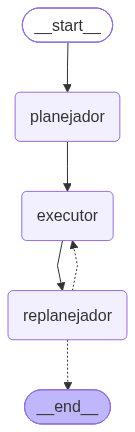

In [13]:
builder = StateGraph(PlanExecuteState)

builder.add_node("planejador", no_planejador)
builder.add_node("executor", no_executor)
builder.add_node("replanejador", no_replanejador)

builder.add_edge(START, "planejador")
builder.add_edge("planejador", "executor")
builder.add_edge("executor", "replanejador")

builder.add_conditional_edges(
    "replanejador",
    deve_continuar,
    {"executor": "executor", END: END},
)

plan_execute_graph = builder.compile()

display_graph(plan_execute_graph)

## 3.8 Executando o agente Plan-and-Execute

In [14]:
resultado = plan_execute_graph.invoke({
    "tarefa": (
        "Sou o Bruno. Preciso de um plano de revisão completo antes da prova final, "
        "considerando meu progresso e os módulos que ainda faltam."
    ),
})

print("Plano gerado:")
print_json(resultado["plano"])

print("\nResposta final:")
print(resultado["resposta_final"])

Plano gerado:

[
  "{"
]

Resposta final:

Olá Bruno! Com base no seu progresso até o módulo A5 e considerando que você está enfrentando dificuldades com o 
roteamento condicional usando LLM, aqui está um plano de revisão para ajudá-lo a se preparar melhor para a prova 
final:

1. **Revisão dos Módulos Passados (Até A4):**
   - Revise todos os conceitos e exercícios do módulo A1 a A4 com especial foco em áreas onde você sente que 
precisa de mais prática.
   
2. **Módulo Atual (A5) - Roteamento Condicional:**
   - Revise as lições e exemplos sobre roteamento condicional.
   - Pratique questões relacionadas ao uso do LLM para roteamento condicional até que você se sinta confiante com o
tema.

3. **Estudo de Módulos Futuros (A6 em diante):**
   - Antecipe-se e revise os tópicos dos próximos módulos, pois a prova final cobrará conteúdo de todo o curso.
   
4. **Simulações da Prova Final:**
   - Faça simulados completos para se familiarizar com o formato e o tempo da prova.

5. **Revisão Geral:**
   - Dedique algum tempo diário para revisar todos os tópicos em bloco, garantindo que você tenha uma compreensão 
clara de cada um.
   
Esse plano ajudará a garantir que você está preparado não apenas com o módulo atual mas também com todo o conteúdo 
do curso até agora. Boa sorte na sua revisão!

## Discussão

Diferente do ReAct, aqui o plano existe como um objeto explícito **antes** de qualquer execução — dá para inspecionar, logar, ou até pedir aprovação humana sobre o plano antes de executar qualquer passo.

O custo principal é a rigidez: se o plano inicial estiver errado (por exemplo, esquecer um passo necessário), o replanejador precisa lidar com isso — no nosso exemplo simplificado, o replanejador só decide "continuar ou finalizar", mas em implementações mais completas ele também pode reescrever os passos restantes.

# 4. ReWOO (Reasoning WithOut Observation)

## 4.1 Conceito

O ReWOO leva a separação entre planejamento e execução um passo além do Plan-and-Execute: o planejador gera o **plano inteiro de uma vez**, sem nunca ver os resultados intermediários das tools.

Em vez disso, o plano referencia resultados futuros por meio de **variáveis** (`#E1`, `#E2`, ...), que só são substituídas por valores reais durante a execução:

```text
Passo 1: consultar_progresso_aluno(nome_aluno="Bruno") -> #E1
Passo 2: consultar_modulos_restantes(modulo_atual=#E1.modulo_atual) -> #E2
Passo 3: calcular_carga_total(quantidade_aulas=soma_aulas(#E2)) -> #E3
```

A vantagem central é de custo: o planejador não precisa do histórico de execução no contexto (porque não precisa reagir a observações) — uma única chamada de LLM produz o plano completo. Depois, um **worker** determinístico executa o plano substituindo as variáveis, e por fim um **solver** sintetiza a resposta usando todas as evidências coletadas.

```text
START
  ↓
planejador (gera plano completo com variáveis, uma única chamada)
  ↓
worker (executa todos os passos, substituindo variáveis)
  ↓
solver (sintetiza resposta final usando todas as evidências)
  ↓
END
```

## 4.2 Saída estruturada do plano com variáveis

In [15]:
class ArgumentoReWOO(BaseModel):
    chave: str = Field(description="Nome do argumento da tool, ex: 'nome_aluno'.")
    valor: str = Field(
        description="Valor do argumento: um literal (ex: 'Bruno', '50') ou uma referência a um "
        "passo anterior (ex: '#E1' para o resultado inteiro, ou \"#E1['campo']\" para um campo específico)."
    )


class PassoReWOO(BaseModel):
    variavel: str = Field(description="Nome da variável que armazenará o resultado deste passo, ex: '#E1'.")
    tool: str = Field(description="Nome da tool a ser chamada neste passo.")
    argumentos: List[ArgumentoReWOO] = Field(
        description="Lista de argumentos da tool, cada um com 'chave' (nome do parâmetro) e 'valor'."
    )


class PlanoReWOO(BaseModel):
    passos: List[PassoReWOO] = Field(description="Lista ordenada de passos do plano, cada um produzindo uma variável.")


planejador_rewoo = llm.with_structured_output(PlanoReWOO)


## 4.3 Nó planejador (única chamada de LLM)

In [16]:
FERRAMENTAS_DISPONIVEIS_TEXTO = """
- consultar_progresso_aluno(nome_aluno: str): retorna {"aluno", "modulo_atual", "dificuldade_atual"}
- consultar_modulos_restantes(modulo_atual: str): retorna {"modulos_restantes": [...], "total_de_aulas": int}
  (total_de_aulas já vem somado — não é preciso somar manualmente)
- calcular_carga_total(quantidade_aulas: int, minutos_por_aula: int = 50): retorna {"total_formatado": str}
"""


class ReWOOState(TypedDict):
    tarefa: str
    plano: List[PassoReWOO]
    evidencias: Dict[str, str]
    resposta_final: Optional[str]


SYSTEM_PLANEJADOR_REWOO = f"""Gere um plano completo, de uma vez, para cumprir a tarefa do aluno.
Tools disponíveis:
{FERRAMENTAS_DISPONIVEIS_TEXTO}
Cada passo tem uma lista de argumentos, cada argumento é um par chave/valor. Regras estritas:
1. O valor pode ser um literal (número ou texto), por exemplo: chave="nome_aluno", valor="Bruno".
   NUNCA escreva expressões, fórmulas ou código como valor (ex: "time(45, 'minutes')" é proibido).
2. O valor pode referenciar o resultado inteiro de um passo anterior, como "#E1".
3. O valor pode referenciar um campo específico do resultado de um passo anterior,
   usando a sintaxe "#E1['campo']", por exemplo "#E2['total_de_aulas']".
4. Nunca invente um campo que não esteja descrito na lista de tools acima.

Exemplo de plano válido para "montar um plano de revisão para o Bruno":
- #E1 = consultar_progresso_aluno(chave="nome_aluno", valor="Bruno")
- #E2 = consultar_modulos_restantes(chave="modulo_atual", valor="#E1['modulo_atual']")
- #E3 = calcular_carga_total(
      argumentos=[{{"chave": "quantidade_aulas", "valor": "#E2['total_de_aulas']"}},
                  {{"chave": "minutos_por_aula", "valor": "50"}}]
  )
- #E4 = (passo final de síntese da resposta)
"""


def no_planejador_rewoo(state: ReWOOState, max_tentativas: int = 3):
    mensagens = [
        SystemMessage(content=SYSTEM_PLANEJADOR_REWOO),
        HumanMessage(content=state["tarefa"]),
    ]

    ultimo_erro = None

    for tentativa in range(1, max_tentativas + 1):
        try:
            resposta = planejador_rewoo.invoke(mensagens)
        except Exception as exc:
            # Falha de rede, rate limit, ou erro de parsing pontual: tentamos de novo
            # em vez de deixar o grafo inteiro quebrar na primeira falha transitória.
            ultimo_erro = exc
            continue

        if resposta is not None and resposta.passos:
            return {"plano": resposta.passos, "evidencias": {}}

        ultimo_erro = "o modelo retornou um plano vazio ou inválido"

    raise RuntimeError(
        f"Não foi possível gerar um plano ReWOO válido após {max_tentativas} tentativas. "
        f"Último erro: {ultimo_erro}"
    )


## 4.4 Nó worker: executa o plano substituindo variáveis

O worker é **determinístico** — ele não chama o LLM, apenas executa as tools na ordem do plano, resolvendo as referências a variáveis anteriores.

In [17]:
import re

REFERENCIA_RE = re.compile(r"^(#E\d+)(?:\[['\"]?([\w]+)['\"]?\])?$")


def resolver_valor(valor: str, evidencias: Dict[str, str]) -> Any:
    """Resolve uma string de argumento que pode ser um literal, uma referência inteira
    (ex: "#E1") ou uma referência a um campo específico (ex: "#E2['total_de_aulas']")."""
    match = REFERENCIA_RE.match(valor.strip())

    if not match:
        return valor  # valor literal (número ou texto), devolvido como está

    variavel, campo = match.group(1), match.group(2)

    if variavel not in evidencias:
        return valor  # referência a um passo inexistente: mantém como literal e deixa a tool reclamar

    bruto = evidencias[variavel]

    try:
        dado = json.loads(bruto) if isinstance(bruto, str) else bruto
    except (json.JSONDecodeError, TypeError):
        return bruto  # não era JSON (ex: mensagem de erro em texto simples)

    if campo is None:
        return dado

    if isinstance(dado, dict) and campo in dado:
        return dado[campo]

    # campo pedido não existe no resultado: devolve o dado bruto para a tool/validação acusar o problema
    return dado


def resolver_argumentos(argumentos: List[ArgumentoReWOO], evidencias: Dict[str, str]) -> Dict[str, Any]:
    resolvidos = {}

    for arg in argumentos:
        chave, valor = arg.chave, arg.valor
        if isinstance(valor, str) and valor.strip().startswith("#E"):
            resolvidos[chave] = resolver_valor(valor, evidencias)
        else:
            resolvidos[chave] = valor

    return resolvidos


def no_worker(state: ReWOOState):
    evidencias = dict(state["evidencias"])

    for passo in state["plano"]:
        argumentos = resolver_argumentos(passo.argumentos, evidencias)

        if passo.tool not in tools_por_nome:
            resultado = json.dumps({"erro": "tool_desconhecida", "tool": passo.tool}, ensure_ascii=False)
        else:
            try:
                resultado = tools_por_nome[passo.tool].invoke(argumentos)
            except Exception as exc:
                # Falha ao executar um passo não deve derrubar o grafo inteiro: registramos o
                # erro como evidência, e o solver pode lidar com a lacuna na resposta final.
                resultado = json.dumps(
                    {"erro": "falha_ao_executar_tool", "tool": passo.tool, "argumentos": argumentos, "detalhe": str(exc)},
                    ensure_ascii=False,
                )

        evidencias[passo.variavel] = resultado

    return {"evidencias": evidencias}


## 4.5 Nó solver: sintetiza a resposta final

In [18]:
def no_solver(state: ReWOOState):
    evidencias_texto = "\n".join(f"{variavel}: {valor}" for variavel, valor in state["evidencias"].items())

    response = llm.invoke([
        SystemMessage(content="Sintetize a resposta final para o aluno com base nas evidências coletadas."),
        HumanMessage(content=f"Tarefa: {state['tarefa']}\n\nEvidências:\n{evidencias_texto}"),
    ])

    return {"resposta_final": response.content}

## 4.6 Construindo o grafo

Note que, diferente do Plan-and-Execute, aqui não existe replanejamento nem ciclo — o fluxo é uma linha reta, porque o plano já foi decidido por completo antes de qualquer execução.

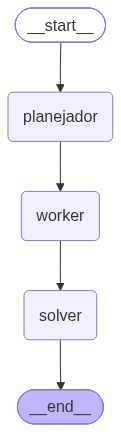

In [19]:
builder = StateGraph(ReWOOState)

builder.add_node("planejador", no_planejador_rewoo)
builder.add_node("worker", no_worker)
builder.add_node("solver", no_solver)

builder.add_edge(START, "planejador")
builder.add_edge("planejador", "worker")
builder.add_edge("worker", "solver")
builder.add_edge("solver", END)

rewoo_graph = builder.compile()

display_graph(rewoo_graph)

## 4.7 Executando o agente ReWOO

In [20]:
resultado_rewoo = rewoo_graph.invoke({
    "tarefa": (
        "Sou o Bruno. Preciso de um plano de revisão completo antes da prova final, "
        "considerando meu progresso e os módulos que ainda faltam."
    ),
})

print("Plano gerado (com variáveis):")
for passo in resultado_rewoo["plano"]:
    print(f"{passo.variavel} = {passo.tool}({passo.argumentos})")

print("\nEvidências coletadas:")
print_json(resultado_rewoo["evidencias"])

print("\nResposta final:")
print(resultado_rewoo["resposta_final"])

Plano gerado (com variáveis):

#E1 = consultar_progresso_aluno([ArgumentoReWOO(chave='nome_aluno', valor='Bruno')])

#E2 = consultar_modulos_restantes([ArgumentoReWOO(chave='modulo_atual', valor="#E1['modulo_atual']")])

#E3 = calcular_carga_total([ArgumentoReWOO(chave='quantidade_aulas', valor="#E2['total_de_aulas']"), 
ArgumentoReWOO(chave='minutos_por_aula', valor='50')])

= (passo final de síntese da resposta)([ArgumentoReWOO(chave='progresso_atual', valor="#E1['dificuldade_atual']"),
ArgumentoReWOO(chave='modulos_restantes', valor="#E2['modulos_restantes']"), 
ArgumentoReWOO(chave='carga_total_formatada', valor="#E3['total_formatado']")])

Evidências coletadas:

{
  "#E1": "{\"aluno\": \"bruno\", \"modulo_atual\": \"A5\", \"dificuldade_atual\": \"roteamento condicional com 
LLM\"}",
  "#E2": "{\"modulos_restantes\": [{\"codigo\": \"A5\", \"titulo\": \"LangGraph com LLMs\", \"aulas\": 4}, 
{\"codigo\": \"A6\", \"titulo\": \"Ferramentas e ReAct\", \"aulas\": 5}, {\"codigo\": \"A7\", \"titulo\": \"Model 
Context Protocol\", \"aulas\": 4}, {\"codigo\": \"A8\", \"titulo\": \"Skills\", \"aulas\": 3}, {\"codigo\": \"A9\",
\"titulo\": \"Planning em agentes\", \"aulas\": 6}], \"total_de_aulas\": 22}",
  "#E3": "{\"quantidade_aulas\": 22, \"minutos_por_aula\": 50, \"total_formatado\": \"18h20min\"}",
  "": "{\"erro\": \"tool_desconhecida\", \"tool\": \"(passo final de síntese da resposta)\"}"
}

Resposta final:

Olá Bruno,

Com base no seu progresso atual e nos módulos que ainda faltam, montei um plano de revisão para te auxiliar na 
preparação para a prova final.

Você está atualmente cursando o módulo A5, LangGraph com LLMs. As dificuldades encontradas estão relacionadas ao 
roteamento condicional com LLM, então é aconselhável dedicar um pouco mais de tempo nesse tema. Os módulos 
subsequentes e suas respectivas aulas são:

- Módulo A6 - Ferramentas e ReAct: 5 aulas
- Módulo A7 - Model Context Protocol: 4 aulas 
- Módulo A8 - Skills: 3 aulas
- Módulo A9 - Planning em agentes: 6 aulas

No total, você tem mais 22 aulas para revisar. Como cada aula leva aproximadamente 50 minutos para ser revisada com
atenção e compreensão, isso significa que você precisará dedicar cerca de 18 horas e 20 minutos para completar 
todas as revisões.

Levando em consideração sua dificuldade atual no módulo A5, é aconselhável dedicar mais tempo à revisão desse 
módulo. 

Aproveite ao máximo esse tempo de estudo, dedique-se e boa sorte na prova final!

Atenciosamente,
Seu Assistente Virtual

## Discussão

A diferença mais importante para o Plan-and-Execute é que **o planejador nunca vê observações intermediárias** — uma única chamada de LLM produz o plano inteiro, o que economiza tokens e latência quando os passos não dependem de decisões que só fariam sentido depois de ver um resultado real.

O custo é flexibilidade: se um resultado intermediário for inesperado (por exemplo, um módulo não encontrado), o ReWOO não tem, por padrão, um mecanismo de replanejamento — o worker segue o plano original mesmo que uma evidência intermediária sugira que o plano deveria mudar. Isso faz do ReWOO uma boa escolha quando os passos são relativamente previsíveis, e uma escolha arriscada quando a tarefa tem muita incerteza sobre os próprios passos.

# 5. Reflection

## 5.1 Conceito

O padrão Reflection já apareceu, sem esse nome, no notebook de LangGraph com LLMs: um ciclo de gerar → avaliar → revisar. Aqui vamos retomar esse padrão explicitamente como **Reflection**, e estendê-lo com um papel mais claro de crítico.

A ideia central: em vez de planejar *ações*, o agente planeja e refina uma **saída** (uma resposta, um texto, um plano de estudo). 

Um papel de **gerador** (actor) produz um rascunho; 

um papel de **crítico** (reflector) aponta problemas específicos; 

o gerador revisa com base na crítica; 

o ciclo se repete até a saída ser considerada boa ou até um limite de tentativas.

```text
START
  ↓
generator (produz rascunho)
  ↓
reflector (critica o rascunho)
  ├── boa → END
  └── revisar → generator (revisa com base na crítica)
```

Diferente do Plan-and-Execute e do ReWOO, aqui não há tools em jogo — o foco é a **qualidade do conteúdo gerado**, não a sequência de ações.

## 5.2 Saída estruturada do crítico

In [21]:
class Critica(BaseModel):
    avaliacao: Literal["boa", "revisar"] = Field(description="Se o rascunho está adequado ou precisa de revisão.")
    pontos_de_melhoria: List[str] = Field(description="Lista curta de pontos específicos a melhorar, se houver.")


critico = llm.with_structured_output(Critica)

## 5.3 Estado do ciclo de reflexão

In [22]:
class ReflectionState(TypedDict, total=False):
    tarefa: str
    rascunho: str
    pontos_de_melhoria: List[str]
    tentativas: int

## 5.4 Nó gerador

In [23]:
def no_generator(state: ReflectionState):
    pontos = state.get("pontos_de_melhoria")

    if not pontos:
        prompt = state["tarefa"]
    else:
        pontos_texto = "\n".join(f"- {p}" for p in pontos)
        prompt = f"""Tarefa original: {state['tarefa']}

Rascunho anterior:
{state['rascunho']}

Pontos a melhorar:
{pontos_texto}

Produza uma versão revisada."""

    response = llm.invoke([
        SystemMessage(content="""Você é o assistente do curso de agentes com LLMs e LangGraph.
Explique de forma didática, objetiva e completa, considerando o nível do aluno."""),
        HumanMessage(content=prompt),
    ])

    return {
        "rascunho": response.content,
        "tentativas": state.get("tentativas", 0) + 1,
    }

## 5.5 Nó crítico (reflector)

In [24]:
def no_reflector(state: ReflectionState):
    resposta = critico.invoke([
        SystemMessage(content="""Avalie o rascunho abaixo como se fosse um revisor técnico exigente.
Critérios: clareza, correção técnica, completude e didática para um aluno do curso.
Se estiver adequado, marque como boa."""),
        HumanMessage(content=f"Tarefa: {state['tarefa']}\n\nRascunho:\n{state['rascunho']}"),
    ])

    return {"pontos_de_melhoria": resposta.pontos_de_melhoria if resposta.avaliacao == "revisar" else []}


def deve_revisar(state: ReflectionState) -> Literal["generator", END]:
    if state.get("pontos_de_melhoria") and state.get("tentativas", 0) < 3:
        return "generator"
    return END

## 5.6 Construindo o grafo

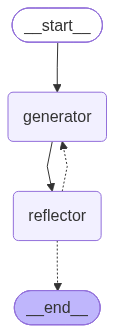

In [25]:
builder = StateGraph(ReflectionState)

builder.add_node("generator", no_generator)
builder.add_node("reflector", no_reflector)

builder.add_edge(START, "generator")
builder.add_edge("generator", "reflector")

builder.add_conditional_edges(
    "reflector",
    deve_revisar,
    {"generator": "generator", END: END},
)

reflection_graph = builder.compile()

display_graph(reflection_graph)

## 5.7 Executando o ciclo de reflexão

In [26]:
resultado_reflection = reflection_graph.invoke({
    "tarefa": "Explique por que ReWOO evita observação intermediária, e quando isso é arriscado.",
})

print("Tentativas:", resultado_reflection["tentativas"])
print("\nRascunho final:\n")
print(resultado_reflection["rascunho"])

Tentativas: 1

Rascunho final:

Para entender melhor a situação envolvendo ReWOO e a observação intermediária, primeiro precisamos definir alguns 
termos e conceitos-chave relacionados ao assunto.

### 1. **O que é Observação Intermediária?**

Observação intermediária refere-se à prática de interromper um processo em andamento para realizar uma análise ou 
tomar uma decisão baseada naquela análise antes da conclusão do processo. Isso pode ocorrer, por exemplo, em 
sistemas de inteligência artificial (IA), onde a IA realiza uma tarefa e faz paradas ao longo do caminho para 
avaliar o progresso.

### 2. **O que é ReWOO?**

ReWOO é um mecanismo ou sistema dentro do contexto de LLMs (Modelos de Linguagem Grandes) e LangGraph, projetado 
para evitar a observação intermediária. Em geral, esses sistemas são criados para garantir a continuidade e 
integridade da tarefa em andamento.

### 3. **Por que ReWOO Evita Observação Intermediária?**

#### **a. Consistência do Processo**
- **Prevenção de Interrupções:** A observação intermediária pode interromper o fluxo natural das operações, 
potencialmente comprometendo a consistência e a qualidade final da tarefa.
  
- **Mantém Foco no Objetivo Final:** Evitando paradas para revisão, ReWOO mantém o foco na conclusão eficiente e 
eficaz do objetivo principal.

#### **b. Eficiência**
- **Menos Overhead de Computação:** Realizar observações intermediárias requer recursos computacionais adicionais 
para análise e processamento das informações coletadas.
  
- **Aceleração da Convergência:** Processos contínuos podem convergir mais rapidamente para resultados 
satisfatórios, sem a necessidade adicional de etapas de análise.

#### **c. Qualidade do Resultado Final**
- **Menor Risco de Erros:** Interrupções e revisões intermediárias podem levar a decisões baseadas em informações 
incompletas ou parciais, aumentando o risco de erros.
  
- **Melhor Integridade das Decisões:** Manter o processo contínuo pode resultar em melhores decisões e resultados 
mais coerentes.

### 4. **Quando Evitar Observação Intermediária É Arriscado?**

#### **a. Situações com Alto Risco**
- **Decisões Críticas:** Em situações onde erros podem ter consequências severas (por exemplo, segurança de 
sistemas críticos), a ausência de verificações intermediárias pode ser perigosa.

- **Problemas Complexos:** Para problemas extremamente complexos que requerem constantes ajustes e refinamentos ao 
longo do caminho, evitar observação intermediária pode levar a resultados insatisfatórios ou inseguros.

#### **b. Necessidade de Ajuste Contínuo**
- **Feedback em Tempo Real:** Em cenários onde feedback contínuo é crucial para o sucesso da tarefa (como sistemas 
adaptativos de aprendizado), evitar observação intermediária pode comprometer a capacidade de ajustar-se de forma 
eficaz.

#### **c. Variação e Incerteza**
- **Ambientes Dinâmicos:** Em ambientes que mudam rapidamente ou têm muita incerteza, verificações intermediárias 
podem ser necessárias para se adaptar a essas mudanças.
  
- **Dados em Mudança:** Se os dados subjacentes à tarefa estão constantemente evoluindo, observações periódicas são
necessárias para garantir que o sistema esteja operando com as informações mais atualizadas.

### Conclusão

ReWOO foi projetado para evitar a observação intermediária porque isso pode melhorar a consistência e eficiência do
processo. No entanto, existem situações onde a ausência de verificações intermediárias pode ser arriscada ou 
ineficaz, especialmente em tarefas que exigem constantes ajustes e feedback para garantir sua segurança e sucesso.

Entender essas nuances é crucial para aplicar ReWOO de forma efetiva e consciente no desenvolvimento de sistemas 
inteligentes.

## Discussão

O ganho do Reflection não está em decidir *quais ações tomar*, mas em melhorar a *qualidade de uma saída* através de autocrítica estruturada. Isso é especialmente útil para tarefas de geração de conteúdo (explicações, planos escritos, resumos), onde a "ação certa" é óbvia (gerar um texto), mas a qualidade do resultado varia bastante entre a primeira tentativa e uma versão revisada.

O custo é multiplicar o número de chamadas ao LLM por até `tentativas` vezes — por isso o critério de parada (avaliação boa ou limite de tentativas) é essencial para controlar custo e latência.

# 6. Tree of Thoughts (ToT)

## 6.1 Conceito

Tree of Thoughts generaliza a ideia de "pensar antes de agir" para **explorar múltiplos caminhos de raciocínio em paralelo**, em vez de seguir um único caminho (como ReAct, Plan-and-Execute e ReWOO fazem).

A ideia central:

1. Gerar **vários "pensamentos"** candidatos para resolver (parte de) um problema — não apenas um.
2. **Avaliar** cada candidato com algum critério (heurística ou o próprio LLM como avaliador).
3. **Selecionar** o(s) melhor(es) candidato(s) para seguir adiante (poda dos ramos fracos).
4. Repetir para os próximos níveis da árvore, se necessário.

```text
                tarefa
             /    |     \
        pensamento_1  pensamento_2  pensamento_3
            |            |              |
         score=0.4    score=0.9      score=0.6
                          |
                  segue com o melhor
```

Para fins didáticos, vamos implementar uma versão simplificada de **um único nível de branching**: gerar 3 estratégias diferentes de distribuir a revisão ao longo das semanas, avaliar cada uma, e escolher a melhor. Em uma implementação mais completa, esse processo se repetiria em múltiplos níveis, com busca em profundidade ou largura.

## 6.2 Saída estruturada de um pensamento (estratégia candidata)

In [27]:
class EstrategiaRevisao(BaseModel):
    nome: str = Field(description="Nome curto da estratégia de revisão.")
    descricao: str = Field(description="Descrição de como a revisão seria distribuída ao longo das semanas.")


class CandidatosDeEstrategia(BaseModel):
    estrategias: List[EstrategiaRevisao] = Field(description="Lista de estratégias candidatas distintas entre si.")


gerador_de_pensamentos = llm.with_structured_output(CandidatosDeEstrategia)

## 6.3 Saída estruturada da avaliação

In [28]:
class AvaliacaoEstrategia(BaseModel):
    nome: str = Field(description="Nome da estratégia avaliada, deve bater com uma das estratégias candidatas.")
    score: float = Field(description="Nota de 0 a 10 para a estratégia, considerando viabilidade e cobertura da revisão.")
    justificativa: str = Field(description="Justificativa curta para a nota.")


class AvaliacaoDeCandidatos(BaseModel):
    avaliacoes: List[AvaliacaoEstrategia]


avaliador_de_pensamentos = llm.with_structured_output(AvaliacaoDeCandidatos)

## 6.4 Estado do agente ToT

In [29]:
class ToTState(TypedDict):
    tarefa: str
    contexto: str
    candidatos: List[EstrategiaRevisao]
    avaliacoes: List[AvaliacaoEstrategia]
    melhor_estrategia: Optional[str]

## 6.5 Nó gerador de pensamentos (branching)

In [30]:
def no_gerar_pensamentos(state: ToTState):
    resposta = gerador_de_pensamentos.invoke([
        SystemMessage(content="""Gere exatamente 3 estratégias distintas e viáveis de distribuir a revisão
de um aluno ao longo das semanas antes da prova final. As estratégias devem ser
claramente diferentes entre si (ex: intensiva no início, distribuída igualmente,
crescente ao longo do tempo)."""),
        HumanMessage(content=f"Tarefa: {state['tarefa']}\n\nContexto do aluno:\n{state['contexto']}"),
    ])

    return {"candidatos": resposta.estrategias}

## 6.6 Nó avaliador (poda)

In [31]:
def no_avaliar_pensamentos(state: ToTState):
    candidatos_texto = "\n".join(
        f"- {c.nome}: {c.descricao}" for c in state["candidatos"]
    )

    resposta = avaliador_de_pensamentos.invoke([
        SystemMessage(content="""Avalie cada estratégia candidata com uma nota de 0 a 10,
considerando viabilidade prática e cobertura adequada da revisão."""),
        HumanMessage(content=f"Contexto do aluno:\n{state['contexto']}\n\nEstratégias candidatas:\n{candidatos_texto}"),
    ])

    melhor = max(resposta.avaliacoes, key=lambda a: a.score)

    return {"avaliacoes": resposta.avaliacoes, "melhor_estrategia": melhor.nome}

## 6.7 Construindo o grafo

Diferente das estratégias anteriores, aqui o "plano" não é uma sequência de ações — é a escolha entre **abordagens alternativas** para resolver a mesma tarefa.

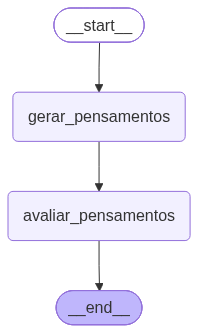

In [32]:
builder = StateGraph(ToTState)

builder.add_node("gerar_pensamentos", no_gerar_pensamentos)
builder.add_node("avaliar_pensamentos", no_avaliar_pensamentos)

builder.add_edge(START, "gerar_pensamentos")
builder.add_edge("gerar_pensamentos", "avaliar_pensamentos")
builder.add_edge("avaliar_pensamentos", END)

tot_graph = builder.compile()

display_graph(tot_graph)

## 6.8 Executando o agente ToT

In [33]:
resultado_tot = tot_graph.invoke({
    "tarefa": "Escolher a melhor forma de distribuir a revisão do Bruno antes da prova final.",
    "contexto": "Bruno está no módulo A5, com dificuldade em roteamento condicional com LLM.",
})

print("Estratégias candidatas:")
for c in resultado_tot["candidatos"]:
    print(f"- {c.nome}: {c.descricao}")

print("\nAvaliações:")
for a in resultado_tot["avaliacoes"]:
    print(f"- {a.nome}: nota {a.score} ({a.justificativa})")

print("\nMelhor estratégia escolhida:", resultado_tot["melhor_estrategia"])

Estratégias candidatas:

- Estratégia Intensiva Inicial: Essa estratégia foca-se em um estudo intensivo no início do período de preparação 
para a prova final, dando ao Bruno a chance de aprender e entender os conceitos difíceis logo de cara. Em seguida, 
ele pode usar o restante das semanas para revisar e fortalecer seu conhecimento com atividades leves de revisão e 
prática. Isso permitirá que ele identifique quais tópicos precisam de maior atenção antes da prova final.

- Estratégia Distribuída Igualmente: Com esta estratégia, Bruno deve dividir seu tempo de estudo igualmente ao 
longo das semanas anteriores à prova. Isso pode ajudá-lo a manter uma rotina constante e evitar o acúmulo de 
material nos últimos dias. Além disso, pode facilitar a assimilação gradual do conteúdo difícil.

- Estratégia Crescente ao Longo do Tempo: Esta estratégia sugere que Bruno comece com estudos leves no início das 
semanas e gradualmente aumente o volume de estudo à medida que se aproxima da prova final. Isso pode ajudá-lo a ter
tempo suficiente para absorver o material mais difícil, enquanto também permite um repasse adequado do conteúdo nos
dias finais.

Avaliações:

- Estratégia Intensiva Inicial: nota 7.0 (Esta estratégia é eficaz para identificar áreas problemáticas desde o 
início, mas pode ser muito estressante. Além disso, se Bruno não entender completamente os conceitos no começo, ele
pode ter dificuldades em continuar a aprendizagem ao longo das semanas.)

- Estratégia Distribuída Igualmente: nota 8.0 (Esta estratégia permite uma assimilação gradual do conteúdo e é 
menos estressante. Bruno terá tempo suficiente para entender os conceitos difíceis sem se sobrecarregar. No 
entanto, essa abordagem pode não ser eficaz se Bruno tem dificuldades em manter a motivação ao longo de várias 
semanas.)

- Estratégia Crescente ao Longo do Tempo: nota 9.0 (Esta estratégia é bastante equilibrada, oferecendo tempo para 
Bruno se familiarizar com o material e aumentar a intensidade de seus estudos conforme necessário. Isto permitirá 
que ele dedique mais tempo para entender os conceitos mais difíceis à medida que a prova final se aproxima.)

Melhor estratégia escolhida: Estratégia Crescente ao Longo do Tempo

## Discussão

O ganho do ToT é considerar **várias abordagens antes de se comprometer com uma**, o que reduz o risco de seguir cegamente a primeira ideia do modelo — especialmente valioso em problemas onde existe mais de uma solução razoável e escolher errado é caro.

O custo é claramente mais alto: em vez de uma chamada de LLM por decisão, temos pelo menos duas (gerar candidatos + avaliar), e uma implementação mais completa, com múltiplos níveis de árvore e busca em largura, multiplicaria ainda mais esse custo. Por isso, ToT costuma ser reservado para decisões de alto impacto, não para todo passo de um agente.

# 7. Comparando as cinco estratégias

| Estratégia | Plano explícito? | Vê observações intermediárias? | Nº aprox. de chamadas de LLM | Foco |
|---|---|---|---|---|
| ReAct | Não | Sim, a cada turno | 1 por turno | Ação |
| Plan-and-Execute | Sim, gerado antes | Sim, entre passos (replanejamento) | 1 (plano) + 1 por passo + 1 (replan/passo) | Ação |
| ReWOO | Sim, gerado antes | Não | 1 (plano) + 1 (síntese final) | Ação |
| Reflection | Não (plano de ação) — mas há ciclo de refinamento | Sim, entre tentativas | 2 por tentativa (gerar + criticar) | Conteúdo |
| Tree of Thoughts | Sim, múltiplos candidatos | Depende da profundidade | 2+ por nível (gerar N + avaliar N) | Escolha entre abordagens |

Um jeito simples de decidir entre elas:

- **A tarefa é curta e o próximo passo depende muito do resultado anterior?** → ReAct.
- **A tarefa é longa, mas os passos são previsíveis e podem ser auditados antes de executar?** → Plan-and-Execute.
- **Os passos são independentes o bastante para planejar tudo de uma vez, e token/latência importam muito?** → ReWOO.
- **O problema é gerar um conteúdo, não executar ações, e qualidade importa mais que velocidade?** → Reflection.
- **Existem várias abordagens razoáveis e escolher errado é caro?** → Tree of Thoughts.

Nada impede combinar estratégias: por exemplo, usar Plan-and-Execute para a estrutura geral da tarefa, e Reflection dentro de um dos passos que envolve gerar um texto longo.

# 8. Boas práticas na escolha da estratégia

## 8.1 Comece simples

ReAct continua sendo a estratégia padrão para a maioria das tarefas. As demais existem para problemas específicos — adicionar complexidade sem necessidade só aumenta custo e latência sem ganho real.

## 8.2 Meça antes de trocar de estratégia

Se está considerando trocar de ReAct para algo mais elaborado, tenha um critério objetivo (número de turnos, taxa de erro, custo em tokens) para justificar a troca.

## 8.3 Combine estratégias por camada

Nada impede usar Plan-and-Execute no nível macro da tarefa, e Reflection dentro de um passo específico que gera um texto longo — as estratégias não são mutuamente exclusivas.

## 8.4 Controle sempre o critério de parada

Reflection e Tree of Thoughts, em particular, podem rodar indefinidamente sem um limite explícito de tentativas ou profundidade. Sempre defina esse limite.

## 8.5 Deixe o plano auditável quando possível

Plan-and-Execute e ReWOO produzem planos explícitos — aproveite isso para logar, revisar, ou até pedir aprovação humana antes de executar passos sensíveis.

# 9. Exercícios de fixação

## Exercício 1 — Replanejamento real no Plan-and-Execute

O `no_replanejador` deste notebook só decide "continuar ou finalizar". Estenda-o para também poder **reescrever os passos restantes** do plano, caso um resultado intermediário sugira que o plano original não é mais adequado.

In [34]:
# Escreva sua solução aqui.

## Exercício 2 — ReWOO com dependência quebrada

Modifique o plano do ReWOO manualmente para incluir uma variável que não existe (ex: referenciar `#E5` quando só existem `#E1` a `#E3`). Trate esse erro no `no_worker` de forma que o solver ainda consiga produzir uma resposta parcial.

In [35]:
# Escreva sua solução aqui.

## Exercício 3 — Reflection com critério de qualidade mais rígido

Adicione um critério extra ao `critico` da seção de Reflection (por exemplo, "deve incluir pelo menos um exemplo prático"). Rode o ciclo e observe se o número de tentativas aumenta.

In [36]:
# Escreva sua solução aqui.

## Exercício 4 — Tree of Thoughts com um segundo nível

Estenda o exemplo de ToT para, depois de escolher a melhor estratégia, gerar 3 variações **dela mesma** (um segundo nível de branching) e avaliar novamente.

In [37]:
# Escreva sua solução aqui.

## Exercício 5 — Custo comparado

Instrumente (com um contador simples) o número de chamadas ao LLM feitas por cada uma das cinco estratégias para a mesma tarefa do Bruno. Compare os resultados.

In [38]:
# Escreva sua solução aqui.

## Exercício 6 — Escolhendo a estratégia certa

Para cada uma das situações abaixo, indique qual das cinco estratégias você usaria e justifique:

1. Um chatbot de suporte que responde perguntas simples sobre o curso.
2. Um agente que gera o relatório semanal de progresso de todos os alunos da turma.
3. Um agente que decide, entre múltiplas abordagens de correção, qual usar para dar feedback em uma redação.
4. Um agente que escreve o material de apoio de um novo módulo do curso.

In [39]:
# Escreva sua resposta aqui.

# 10. Síntese

Neste notebook, vimos cinco estratégias de planejamento para agentes:

- **ReAct**: pensa e age a cada turno, sem plano explícito — simples, mas sem visão de conjunto.
- **Plan-and-Execute**: planeja tudo antes, executa passo a passo, com replanejamento entre passos.
- **ReWOO**: planeja tudo de uma vez, sem ver observações intermediárias, usando variáveis — mais barato, menos flexível.
- **Reflection**: gera, critica e revisa a própria saída — focado em qualidade de conteúdo, não em sequência de ações.
- **Tree of Thoughts**: gera múltiplas abordagens candidatas, avalia e escolhe a melhor — mais caro, mas reduz o risco de se comprometer cedo com uma abordagem ruim.

Nenhuma estratégia é universalmente melhor — a escolha depende do formato da tarefa (ação vs. conteúdo), da previsibilidade dos passos, e de quanto custo em tokens e latência é aceitável.

## 10.1 Checklist de compreensão

Antes de avançar, verifique se você consegue responder:

1. Por que o ReAct pode ser ineficiente em tarefas longas?
2. Qual a diferença entre o plano do Plan-and-Execute e o plano do ReWOO?
3. O que significa "reasoning without observation" no ReWOO?
4. Por que o Reflection não é, estritamente, uma estratégia de planejamento de ações?
5. O que diferencia o Tree of Thoughts das demais estratégias?
6. Em que situação você combinaria duas estratégias diferentes no mesmo agente?
7. Qual estratégia tem, em geral, o maior custo em chamadas de LLM? Por quê?
8. Como um plano explícito (Plan-and-Execute ou ReWOO) facilita aprovação humana?

## 10.2 Próximos passos

A partir daqui, você pode evoluir os agentes deste notebook para incluir:

- combinação de estratégias (ex: Plan-and-Execute com um passo usando Reflection);
- replanejamento mais robusto, incluindo mudança de passos e não só decisão de parar;
- memória entre execuções, para reaproveitar planos ou críticas anteriores;
- métricas de custo (tokens, chamadas de LLM, latência) por estratégia;
- aprovação humana antes de executar planos sensíveis;
- integração com as skills e tools MCP vistas nos notebooks anteriores.

# 11. Referências

- Yao et al. — ReAct: Synergizing Reasoning and Acting in Language Models
- Wang et al. — Plan-and-Solve Prompting
- Xu et al. — ReWOO: Decoupling Reasoning from Observations for Efficient Augmented Language Models
- Shinn et al. — Reflexion: Language Agents with Verbal Reinforcement Learning
- Yao et al. — Tree of Thoughts: Deliberate Problem Solving with Large Language Models
- LangGraph — Documentação de grafos com ciclos: https://docs.langchain.com/oss/python/langgraph/quickstart
- Notebooks anteriores da sequência: N3 (LangGraph com LLMs), N4 (Ferramentas), N7 (Skills)